NOTEBOOK 2: FEATURE ENGINEERING

[STEP 1] Loading cleaned data...
✓ Loaded 5209 rows
✓ Date range: 2025-06-01 22:00:00 to 2026-01-04 22:00:00

[STEP 2] Creating time features...
✓ Created 7 time features

[STEP 3] Creating cyclical features (sine/cosine)...
✓ Created 4 cyclical features

[STEP 4] Creating lag features...
✓ Created 9 lag features

[STEP 5] Creating rolling statistics...
✓ Created 20 rolling features

[STEP 6] Creating rate of change features...
✓ Created 4 rate of change features

[STEP 7] Creating range features...
✓ Created 3 range features

[STEP 8] Creating volatility features...
✓ Created 3 volatility features

[STEP 9] Creating target variable...
✓ Created target variable (price 24h ahead)

[STEP 10] Handling missing values...
✓ Removed 198 rows with missing values
✓ Final dataset: 5011 rows

FEATURE SUMMARY

✓ Total features created: 50

Feature breakdown:
  • Time features: 7
  • Cyclical features: 4
  • Lag features: 9
  • Rolling statistics: 20
  • Rate of cha

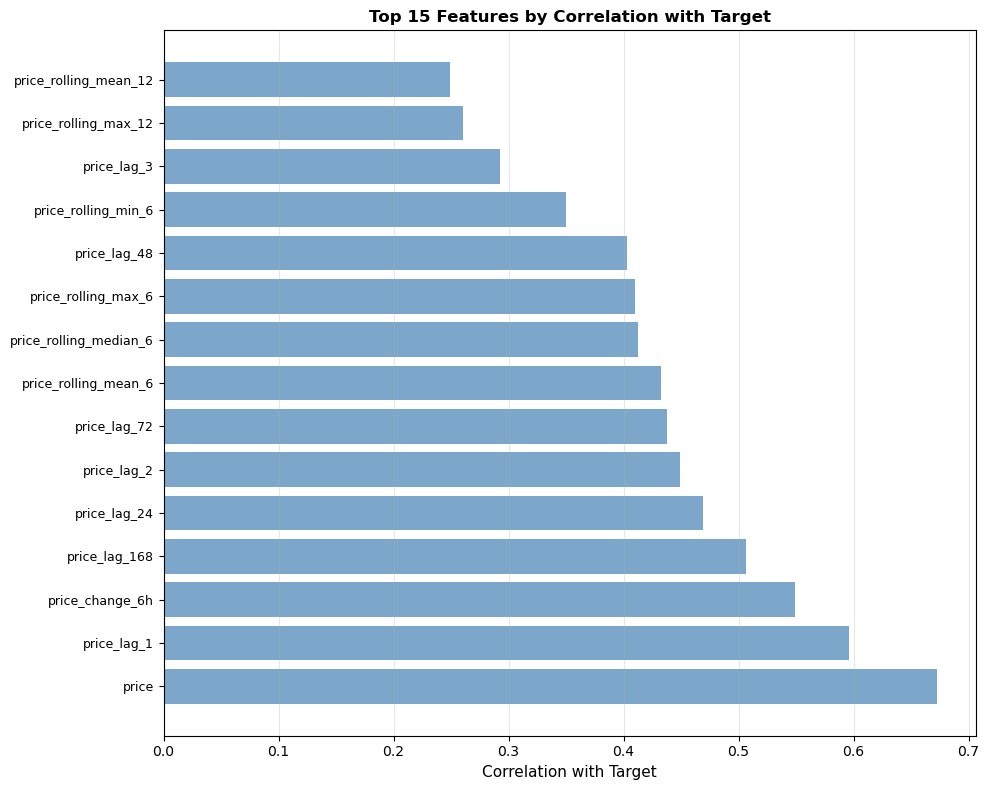

✓ Saved: plots/04_feature_correlation.png

[STEP 12] Saving feature dataset...
✓ Saved: data/features.csv
✓ Saved feature names

FEATURE ENGINEERING COMPLETE!

✓ Dataset prepared:
  • Rows: 5011
  • Columns: 53
  • Features: 50


In [2]:
# NOTEBOOK 2: FEATURE ENGINEERING

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("="*70)
print("NOTEBOOK 2: FEATURE ENGINEERING")
print("="*70)

# ===== LOAD CLEANED DATA =====
print("\n[STEP 1] Loading cleaned data...")
df = pd.read_csv('data/electricity_prices.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f"✓ Loaded {len(df)} rows")
print(f"✓ Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

# ===== TIME FEATURES =====
print("\n[STEP 2] Creating time features...")
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_of_month'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['quarter'] = df['timestamp'].dt.quarter
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)
print(f"✓ Created 7 time features")

# ===== CYCLICAL FEATURES =====
print("\n[STEP 3] Creating cyclical features (sine/cosine)...")
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
print(f"✓ Created 4 cyclical features")

# ===== LAG FEATURES =====
print("\n[STEP 4] Creating lag features...")
lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
for lag in lags:
    df[f'price_lag_{lag}'] = df['price'].shift(lag)
print(f"✓ Created {len(lags)} lag features")

# ===== ROLLING STATISTICS =====
print("\n[STEP 5] Creating rolling statistics...")
rolling_windows = [6, 12, 24, 48]
for window in rolling_windows:
    df[f'price_rolling_mean_{window}'] = df['price'].rolling(window=window).mean()
    df[f'price_rolling_std_{window}'] = df['price'].rolling(window=window).std()
    df[f'price_rolling_min_{window}'] = df['price'].rolling(window=window).min()
    df[f'price_rolling_max_{window}'] = df['price'].rolling(window=window).max()
    df[f'price_rolling_median_{window}'] = df['price'].rolling(window=window).median()
rolling_features_count = len(rolling_windows) * 5
print(f"✓ Created {rolling_features_count} rolling features")

# ===== RATE OF CHANGE =====
print("\n[STEP 6] Creating rate of change features...")
df['price_change_1h'] = df['price'].diff(1)
df['price_change_6h'] = df['price'].diff(6)
df['price_change_24h'] = df['price'].diff(24)
df['price_pct_change_24h'] = df['price'].pct_change(24)
print(f"✓ Created 4 rate of change features")

# ===== RANGE FEATURES =====
print("\n[STEP 7] Creating range features...")
for window in [12, 24, 48]:
    df[f'price_range_{window}'] = (df['price'].rolling(window=window).max() - 
                                    df['price'].rolling(window=window).min())
print(f"✓ Created 3 range features")

# ===== VOLATILITY FEATURES =====
print("\n[STEP 8] Creating volatility features...")
for window in [12, 24, 48]:
    df[f'volatility_{window}'] = df['price'].rolling(window=window).std()
print(f"✓ Created 3 volatility features")

# ===== TARGET VARIABLE =====
print("\n[STEP 9] Creating target variable...")
df['target'] = df['price'].shift(-24)
print(f"✓ Created target variable (price 24h ahead)")

# ===== REMOVE INCOMPLETE ROWS =====
print("\n[STEP 10] Handling missing values...")
initial_rows = len(df)
df_clean = df.dropna()
removed_rows = initial_rows - len(df_clean)
print(f"✓ Removed {removed_rows} rows with missing values")
print(f"✓ Final dataset: {len(df_clean)} rows")

# ===== COUNT FEATURES =====
print("\n" + "="*70)
print("FEATURE SUMMARY")
print("="*70)
feature_columns = [col for col in df_clean.columns if col not in ['timestamp', 'price', 'target']]
feature_count = len(feature_columns)
print(f"\n✓ Total features created: {feature_count}")
print(f"\nFeature breakdown:")
print(f"  • Time features: 7")
print(f"  • Cyclical features: 4")
print(f"  • Lag features: {len(lags)}")
print(f"  • Rolling statistics: {rolling_features_count}")
print(f"  • Rate of change: 4")
print(f"  • Range features: 3")
print(f"  • Volatility features: 3")

# ===== FEATURE CORRELATION =====
print("\n[STEP 11] Analyzing feature correlations...")
correlations = df_clean.corr()['target'].sort_values(ascending=False)
print(f"\nTop 10 features correlated with target:")
for i, (feat, corr) in enumerate(correlations.head(11).items(), 1):
    if feat != 'target':
        print(f"  {i}. {feat:30s}: {corr:+.4f}")

# ===== PLOT 1: FEATURE CORRELATION =====
print("\n[PLOT 1] Creating feature correlation plot...")
plt.figure(figsize=(10, 8))
top_corr = correlations.head(16)[1:]
plt.barh(range(len(top_corr)), top_corr.values, color='steelblue', alpha=0.7)
plt.yticks(range(len(top_corr)), top_corr.index, fontsize=9)
plt.xlabel('Correlation with Target', fontsize=11)
plt.title('Top 15 Features by Correlation with Target', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plots/04_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: plots/04_feature_correlation.png")

# ===== SAVE FEATURES =====
print("\n[STEP 12] Saving feature dataset...")
df_clean.to_csv('data/features.csv', index=False)
print(f"✓ Saved: data/features.csv")

# Save feature names for later
feature_names = feature_columns
with open('data/feature_names.txt', 'w') as f:
    for fname in feature_names:
        f.write(fname + '\n')
print(f"✓ Saved feature names")

# ===== FINAL SUMMARY =====
print("\n" + "="*70)
print("FEATURE ENGINEERING COMPLETE!")
print("="*70)
print(f"\n✓ Dataset prepared:")
print(f"  • Rows: {len(df_clean)}")
print(f"  • Columns: {len(df_clean.columns)}")
print(f"  • Features: {feature_count}")